In [114]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir('/zhome/71/c/146676/main/')
import SimpleITK as sitk
from loaders import loader_XA_to_NA
import importlib
importlib.reload(loader_XA_to_NA)
import tifffile
!pip install matplotlib-scalebar
from matplotlib_scalebar.scalebar import ScaleBar

In [4]:
reg = loader_XA_to_NA.load_registered_data(compression = 1, dataset_XA='tv', dataset_NA='tv')

Resampling the transformation
Resampling moving image


In [90]:
XA = sitk.GetArrayFromImage(reg.moving)
NA = sitk.GetArrayFromImage(reg.fixed)


In [11]:
NA_sub = NA[0:500]

In [92]:
nz, ny, nx = np.shape(NA)
from cil.framework import ImageGeometry, ImageData
from cil.optimisation.operators import GradientOperator
ig = ImageGeometry(voxel_num_x=nx, voxel_num_y=ny, voxel_num_z=nz)
NA_IG = ImageData(NA, geometry=ig)

In [93]:
def xi_vector_field(image,eta):
    G = GradientOperator(ig)
    numerator = G.direct(image)
    denominator = np.sqrt(eta**2 + numerator.get_item(0)**2 + numerator.get_item(1)**2)
    xi = numerator/denominator

    return xi.get_item(1)

In [94]:
grad_im = xi_vector_field(NA_IG, 0.005)

In [95]:
min_ = np.min(grad_im.as_array(),axis=(1))

In [96]:
argmin_ = np.argmin(grad_im.as_array(),axis=(1))
from scipy.ndimage import median_filter


# Apply median filter with a 3x3 window
f_argmin_ = np.clip(median_filter(argmin_, size=25),a_min = 10,a_max=300)

In [112]:
nz, ny, nx = np.shape(NA)
NA_surf = NA[np.arange(nz)[:, None], f_argmin_-3, np.arange(nx)]
XA_surf = XA[np.arange(nz)[:, None], f_argmin_-3, np.arange(nx)]

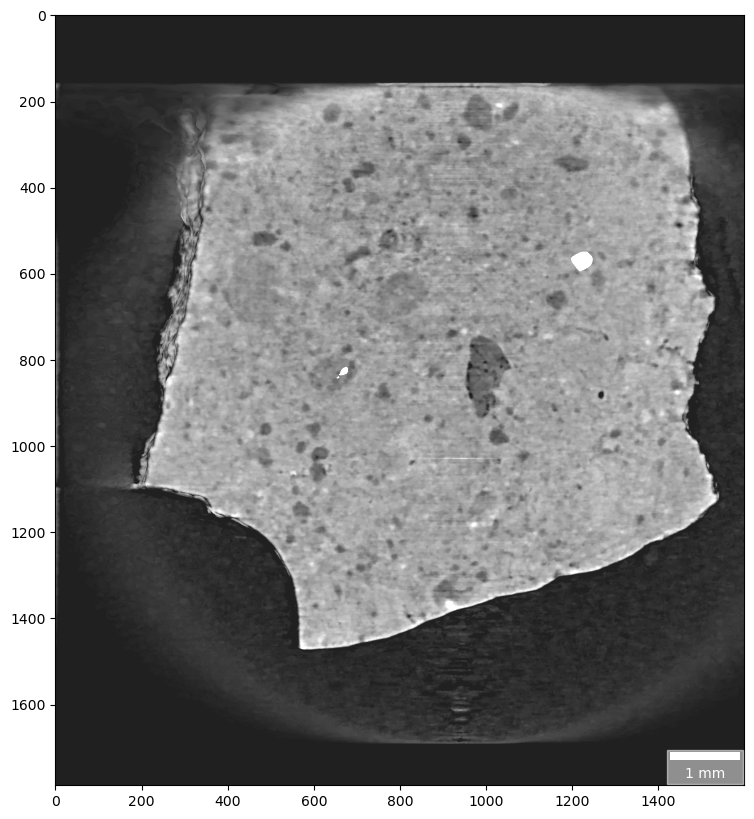

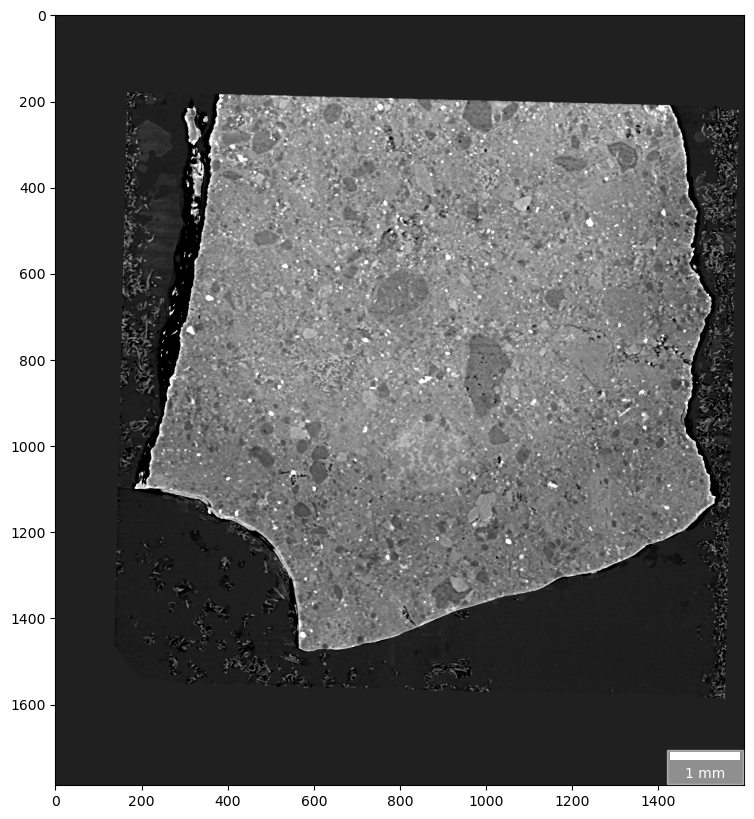

In [123]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(NA_surf, cmap='gray', vmin=-0.01, vmax=0.07)

scalebar = ScaleBar(6.12, "µm", location="lower right", color="white", scale_loc="bottom", box_alpha=0.5)
ax.add_artist(scalebar)

plt.savefig('/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/NA_TV_surface.png',dpi = 250 )

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(XA_surf, cmap='gray', vmin=-0.01, vmax=0.07)

scalebar = ScaleBar(6.12, "µm", location="lower right", color="white", scale_loc="bottom", box_alpha=0.5)
ax.add_artist(scalebar)
plt.savefig('/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/XA_surface.png',dpi = 250 )

In [124]:
xray_slices = range(0,10)
neutron_slices = range(0,nz)
output_volume = [[0,nz],[None], [None]]
reg_ = loader_XA_to_NA.load_subset_of_registered_data(dataset_XA='tv', dataset_NA='dtv' , h=1, xray_slices = xray_slices,
    neutron_slices = neutron_slices, output_volume = output_volume)

Resampling the transformation
Resampling moving image


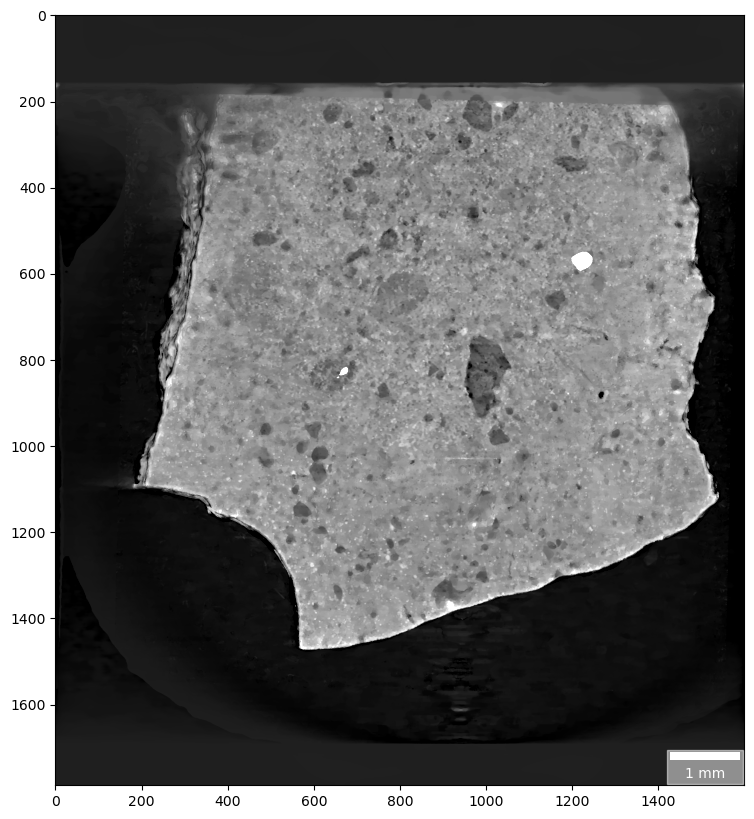

In [125]:
NA_dtv = sitk.GetArrayFromImage(reg_.fixed)
NA_dtv_surf = NA_dtv[np.arange(nz)[:, None], f_argmin_-3, np.arange(nx)]
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(NA_dtv_surf, cmap='gray', vmin=-0.01, vmax=0.07)

scalebar = ScaleBar(6.12, "µm", location="lower right", color="white", scale_loc="bottom", box_alpha=0.5)
ax.add_artist(scalebar)

plt.savefig('/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/NA_dTV_surface.png',dpi = 250 )


In [188]:
path = '/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/edsMg.tiff'
eds = tifffile.imread(path)
eds[eds>150] = 0
eds = np.fliplr(eds)
#eds = np.flipud(eds)
eds = eds[4000::2,::2]/100


In [189]:
_ , nx_XA = np.shape(XA_surf)
_ , nx_eds = np.shape(eds)

fixed = sitk.GetImageFromArray(XA_surf)
moving = sitk.GetImageFromArray(eds)
moving_NA = sitk.GetImageFromArray(XA_surf)
fixed.SetSpacing((1/nx_XA,1/nx_XA))
moving.SetSpacing((1/nx_eds,1/nx_eds))

size_fixed = fixed.GetSize()
size_moving = moving.GetSize()

spacing_fixed = fixed.GetSpacing()
spacing_moving = moving.GetSpacing()

# Compute the new origin (shift it to -N/2)
new_origin_fixed = [-0.5 * (size_fixed[i] - 1) * spacing_fixed[i] for i in range(len(size_fixed))]
new_origin_moving = [-0.5 * (size_moving[i] - 1) * spacing_moving[i] for i in range(len(size_moving))]


fixed.SetOrigin(new_origin_fixed)
moving.SetOrigin(new_origin_moving)

In [190]:
factor = 3

transform = sitk.Transform(2, sitk.sitkIdentity)
# Get the original size and spacing of the image
size = moving.GetSize()
spacing = moving.GetSpacing()

# Calculate the new size (downsampling by factor)
new_size = [int(size[0] / factor), int(size[1] / factor)]
# Calculate the new spacing (enlarging the spacing to match the downsampled size)
new_spacing = [s * factor for s in spacing]

# Perform the resampling (using average interpolation for downsampling)
moving_d = sitk.Resample(moving,
                                new_size,
                                transform,
                                sitk.sitkLinear,  # BSpline interpolation is good for downsampling
                                moving.GetOrigin(),
                                new_spacing,
                                moving.GetDirection(),
                                0)  # 0 is the background value for the resampling


In [191]:
def registrator(fixed, moving, thresholds = [0.025, 30], sampling_percentage = 0.1, max_iter = 1000, learning_rate = 1):

    fixed_d = sitk.BinaryThreshold(fixed, lowerThreshold=thresholds[0], upperThreshold=float("inf"), insideValue=1, outsideValue=0)
    moving_d = sitk.BinaryThreshold(moving, lowerThreshold=thresholds[1], upperThreshold=float("inf"), insideValue=1, outsideValue=0)
    fixed_d =sitk.Cast(fixed_d, sitk.sitkFloat32)
    moving_d =sitk.Cast(moving_d, sitk.sitkFloat32)

    initial_transform = sitk.Similarity2DTransform()
    initial_transform.SetMatrix([1.0, 0.0,
                                0.0, 1.0])

    # Set the translation to zero
    initial_transform.SetTranslation([0.0, 0.0])
    initial_transform.SetScale(1.0)

    registration = sitk.ImageRegistrationMethod()
    registration.SetInitialTransform(initial_transform)
    registration.SetMetricAsMeanSquares()
    registration.SetMetricSamplingStrategy(registration.RANDOM)
    registration.SetMetricSamplingPercentage(sampling_percentage)

    registration.SetOptimizerAsGradientDescent(
        learningRate=learning_rate,
        numberOfIterations=max_iter,
        convergenceMinimumValue=-1e-16,
        convergenceWindowSize=1000
        )

    registration.SetInterpolator(sitk.sitkLinear)
    registration.Execute(fixed_d, moving_d)
    transform = registration.GetInitialTransform()
    return transform

def resampler(fixed, moving, transform):
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(fixed)  # Reference image (fixed)
    resampler.SetInterpolator(sitk.sitkLinear)   # Interpolation method
    resampler.SetTransform(transform)    # Apply the initial transform (aligned centroids)
    resampler.SetOutputPixelType(fixed.GetPixelID())
    resampler.SetOutputSpacing(fixed.GetSpacing())  # Ensure the spacing is preserved
    resampler.SetOutputOrigin(fixed.GetOrigin())  # Preserve origin
    resampler.SetOutputDirection(fixed.GetDirection())
    moving = resampler.Execute(moving)
    return moving

In [193]:
transforms = []

transforms.append(registrator(fixed, moving_d, thresholds = [0.025, 0.20], sampling_percentage = 0.2, max_iter = 500, learning_rate = 3))
moving_temp = resampler(fixed, moving_d, transforms[0])



transforms.append(registrator(fixed, moving_temp, thresholds = [0.025, 0.20], sampling_percentage = 0.2, max_iter = 500, learning_rate = 1))
moving_temp = resampler(fixed, moving_temp, transforms[1])



transforms.append(registrator(fixed, moving_temp, thresholds = [0.025, 0.20], sampling_percentage = 0.2, max_iter = 500, learning_rate = 0.5))
moving_temp = resampler(fixed, moving_temp, transforms[2])


transforms.append(registrator(fixed, moving_temp, thresholds = [0.025, 0.20], sampling_percentage = 0.2, max_iter = 500, learning_rate = 0.2))
moving_temp = resampler(fixed, moving_temp, transforms[3])

transforms.append(registrator(fixed, moving_temp, thresholds = [0.025, 0.20], sampling_percentage = 0.2, max_iter = 500, learning_rate = 0.1))
moving_temp = resampler(fixed, moving_temp, transforms[4])



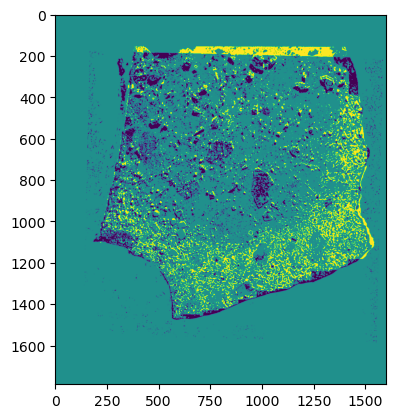

In [194]:
m1 = sitk.GetArrayFromImage(moving_temp)>0.2
m2 = sitk.GetArrayFromImage(fixed)>0.025
diff_ = m1*1-m2*1
plt.imshow(diff_)

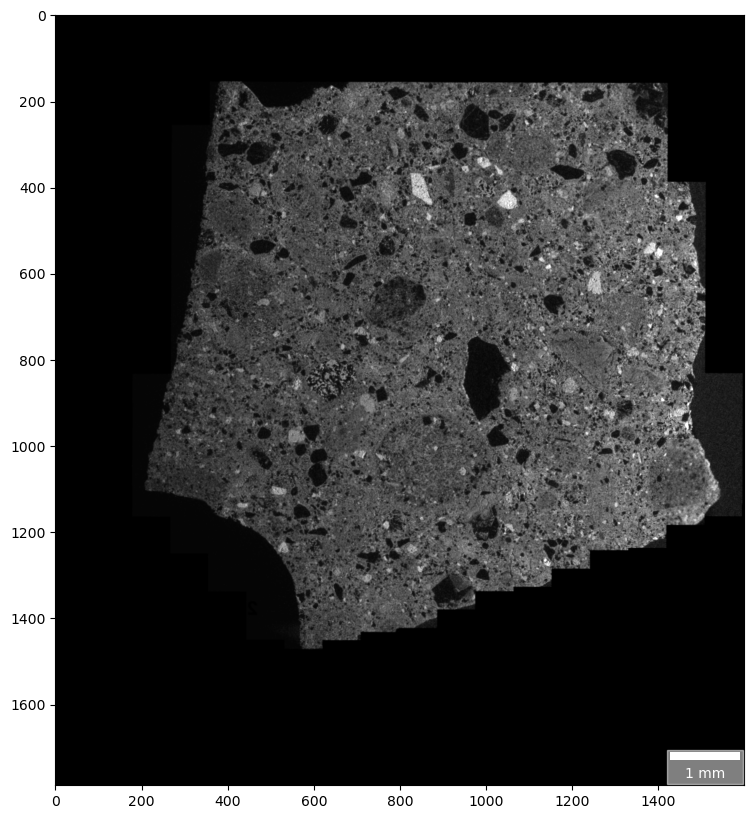

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(sitk.GetArrayFromImage(moving_temp), cmap='gray', vmin=0, vmax=1)

scalebar = ScaleBar(6.12, "µm", location="lower right", color="white", scale_loc="bottom", box_alpha=0.5)
ax.add_artist(scalebar)

plt.savefig('/dtu-compute/msaca/sliceA_eds/EDS_BB_A_raw_files/N_eds_registered_to_XA_NA.png',dpi = 250 )

